# 04 — pySCENIC Regulon Analysis

Loads AUCell output from Harvey 2019 and Cherief 2023 pySCENIC runs.
Identifies TF regulons differentially active between TSPC and T-FAP.

In [1]:
import h5py
import loompy
import numpy as np
import pandas as pd
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

sc.settings.verbosity = 1

ROOT = Path('../..')
DATA = ROOT / 'data' / 'pyscenic'
FIG  = ROOT / 'figures' / 'pyscenic'
FIG.mkdir(parents=True, exist_ok=True)
sc.settings.figdir = str(FIG) + '/'

In [2]:
def load_aucell_loom(aucell_path, input_loom_path=None):
    """
    Load pySCENIC AUCell loom -> AnnData (cells x regulons).

    pySCENIC stores AUC scores as a structured compound array in
    col_attrs/RegulonsAUC (one field per regulon), not as the main matrix.
    We read via h5py to avoid loompy validation issues with compound dtypes.
    """
    with h5py.File(str(aucell_path), 'r') as f:
        col_keys = list(f['col_attrs'].keys())
        row_keys = list(f['row_attrs'].keys())
        print(f'  col_attrs: {col_keys}')
        print(f'  row_attrs: {row_keys}')

        # AUC scores: structured compound array (n_cells,), fields = regulon names
        reg_auc = f['col_attrs']['RegulonsAUC']
        regulon_names = list(reg_auc.dtype.names)
        auc = np.column_stack([reg_auc[r][:] for r in regulon_names])  # cells x regulons

        # Cell IDs
        cell_key = 'CellID' if 'CellID' in col_keys else 'obs_names'
        cells = f['col_attrs'][cell_key][:].astype(str)

        # Cell type (may be present if pySCENIC copied it from input loom)
        cell_type = f['col_attrs']['cell_type'][:].astype(str) if 'cell_type' in col_keys else None

    adata = sc.AnnData(
        X=auc.astype(np.float32),
        obs=pd.DataFrame(index=cells),
        var=pd.DataFrame(index=regulon_names)
    )

    if cell_type is not None:
        adata.obs['cell_type'] = cell_type
    elif input_loom_path is not None:
        # Fall back to input loom for cell_type labels
        with loompy.connect(str(input_loom_path), 'r') as ds:
            ct_map = pd.Series(
                ds.ca['cell_type'].astype(str),
                index=ds.ca['obs_names'].astype(str)
            )
        adata.obs['cell_type'] = adata.obs.index.map(ct_map)

    adata.obs['cell_type'] = adata.obs['cell_type'].astype('category')
    print(f'  {adata.n_obs} cells x {adata.n_vars} regulons')
    print(adata.obs['cell_type'].value_counts().to_string())
    return adata

In [3]:
print('=== Harvey 2019 ===')
adata_h = load_aucell_loom(
    DATA / 'harvey_aucell.loom',
    DATA / 'harvey_tspc_tfap.loom'
)

print('\n=== Cherief 2023 ===')
adata_c = load_aucell_loom(
    DATA / 'cherief_aucell.loom',
    DATA / 'cherief_tspc_tfap.loom'
)

=== Harvey 2019 ===
  col_attrs: ['RegulonsAUC', 'cell_type', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'n_genes', 'n_genes_by_counts', 'obs_names', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'total_counts', 'total_counts_mt']
  row_attrs: ['Regulons', 'feature_types', 'gene_ids', 'log1p_mean_counts', 'log1p_total_counts', 'mean_counts', 'mt', 'n_cells', 'n_cells_by_counts', 'pct_dropout_by_counts', 'total_counts', 'var_names']
  699 cells x 153 regulons
cell_type
T-FAP    433
TSPC     266

=== Cherief 2023 ===
  col_attrs: ['RegulonsAUC', 'cell_type', 'condition', 'leiden', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'log1p_total_counts_mt', 'n_genes', 'n_genes_by_counts', 'obs_names', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'pct_counts_in_top_50_genes', 'pct_counts_mt', 'sample', 'total_cou

C:\Users\fangy\AppData\Local\Temp\ipykernel_16648\1705851438.py:11: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


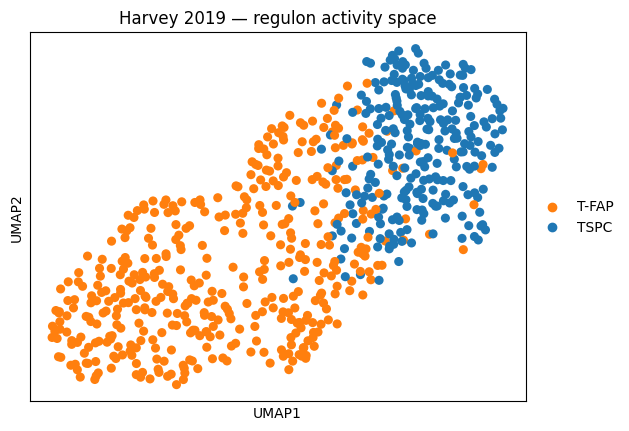

C:\Users\fangy\AppData\Local\Temp\ipykernel_16648\1705851438.py:11: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(


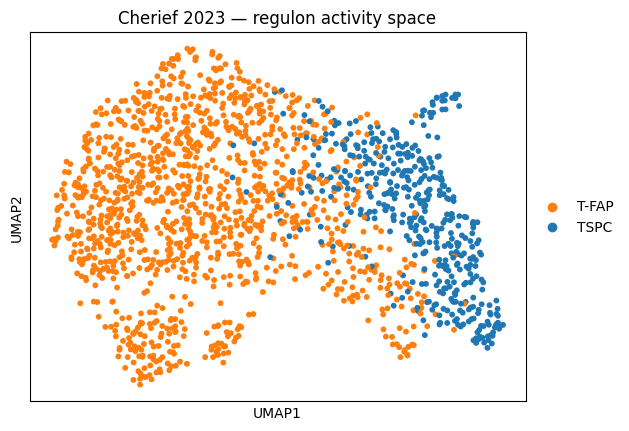

In [4]:
# UMAP on regulon activity space
palette = {'TSPC': '#1f77b4', 'T-FAP': '#ff7f0e'}

for adata, name, label in [
    (adata_h, 'harvey',  'Harvey 2019'),
    (adata_c, 'cherief', 'Cherief 2023'),
]:
    sc.tl.pca(adata, n_comps=min(30, adata.n_vars - 1))
    sc.pp.neighbors(adata, n_neighbors=15, n_pcs=20)
    sc.tl.umap(adata)
    sc.pl.umap(
        adata, color='cell_type', palette=palette,
        title=f'{label} — regulon activity space',
        save=f'_regulons_{name}.png'
    )

In [5]:
def diff_regulons(adata, label):
    """Wilcoxon test: regulons differential between TSPC and T-FAP."""
    sc.tl.rank_genes_groups(
        adata, groupby='cell_type',
        groups=['TSPC', 'T-FAP'], reference='rest',
        method='wilcoxon', use_raw=False
    )
    results = {}
    for group in ['TSPC', 'T-FAP']:
        df = sc.get.rank_genes_groups_df(adata, group=group)
        df = (
            df[df['pvals_adj'] < 0.05]
            .sort_values('scores', ascending=False)
            .reset_index(drop=True)
        )
        results[group] = df
        print(f'\n--- {label}: top {group} regulons (n={len(df)} significant) ---')
        print(df[['names', 'scores', 'logfoldchanges', 'pvals_adj']].head(15).to_string(index=False))
    return results

diff_h = diff_regulons(adata_h, 'Harvey')
diff_c = diff_regulons(adata_c, 'Cherief')


--- Harvey: top TSPC regulons (n=92 significant) ---
     names    scores  logfoldchanges    pvals_adj
  Arnt2(+) 13.279843        1.293074 3.566422e-39
  Fosl1(+) 12.895783        1.243249 4.849132e-37
  Tfdp1(+) 12.773487        0.506250 2.205008e-36
   Fli1(+) 12.026009        0.518299 2.334613e-32
   E2f1(+) 11.187483        0.612021 3.991404e-28
   Etv4(+) 10.122495        0.904813 3.358950e-23
 Nfatc2(+) 10.081600        1.269050 4.854600e-23
    Max(+)  9.560970        0.866689 7.760308e-21
 Gabpb1(+)  8.514693        0.471823 9.465136e-17
   Ets1(+)  8.324110        0.662547 4.642695e-16
   Etv5(+)  7.325865        0.356705 1.171497e-12
 Zfp110(+)  6.167708        0.912085 3.312780e-09
    Sp3(+)  6.154977        0.258696 3.481374e-09
   Elk4(+)  6.004517        0.751314 8.635619e-09
Smarca4(+)  5.903824        0.241850 1.552603e-08

--- Harvey: top T-FAP regulons (n=92 significant) ---
   names    scores  logfoldchanges     pvals_adj
 Ebf1(+) 21.628645        1.083851 1.47767

In [6]:
# Cross-dataset comparison: regulons consistently differential in both datasets
# Require: (1) in top 50 of both, (2) positive score in both (same direction)
print('=== Regulons in top 50 of BOTH datasets with consistent direction ===')
shared = {}
for ct in ['TSPC', 'T-FAP']:
    h_df = diff_h[ct].head(50).set_index('names')
    c_df = diff_c[ct].head(50).set_index('names')
    common = h_df.index.intersection(c_df.index)
    # Keep only those with positive score in both datasets
    consistent = [
        r for r in common
        if h_df.loc[r, 'scores'] > 0 and c_df.loc[r, 'scores'] > 0
    ]
    shared[ct] = sorted(consistent)
    print(f'\n{ct} (n={len(shared[ct])}):')
    for r in shared[ct]:
        print(f'  {r:20s}  harvey={h_df.loc[r, "scores"]:6.2f}  cherief={c_df.loc[r, "scores"]:6.2f}')

=== Regulons in top 50 of BOTH datasets with consistent direction ===

TSPC (n=0):

T-FAP (n=15):
  Atf3(+)               harvey= 11.00  cherief= 25.70
  Cebpd(+)              harvey= 20.78  cherief= 29.31
  Egr1(+)               harvey= 20.60  cherief= 25.89
  Fos(+)                harvey= 14.26  cherief= 17.52
  Fosb(+)               harvey= 17.84  cherief= 26.72
  Irf1(+)               harvey= 20.55  cherief= 20.83
  Jun(+)                harvey= 16.78  cherief= 26.30
  Junb(+)               harvey= 17.37  cherief= 27.27
  Jund(+)               harvey= 18.15  cherief= 28.43
  Klf6(+)               harvey=  4.94  cherief= 18.60
  Klf9(+)               harvey=  9.25  cherief= 24.29
  Nfkb1(+)              harvey= 15.08  cherief= 21.24
  Pbx1(+)               harvey=  7.82  cherief= 12.39
  Prdm16(+)             harvey=  2.33  cherief=  8.22
  Zfp369(+)             harvey=  5.43  cherief=  4.96


C:\Users\fangy\AppData\Local\Temp\ipykernel_16648\346676417.py:5: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.matrixplot(


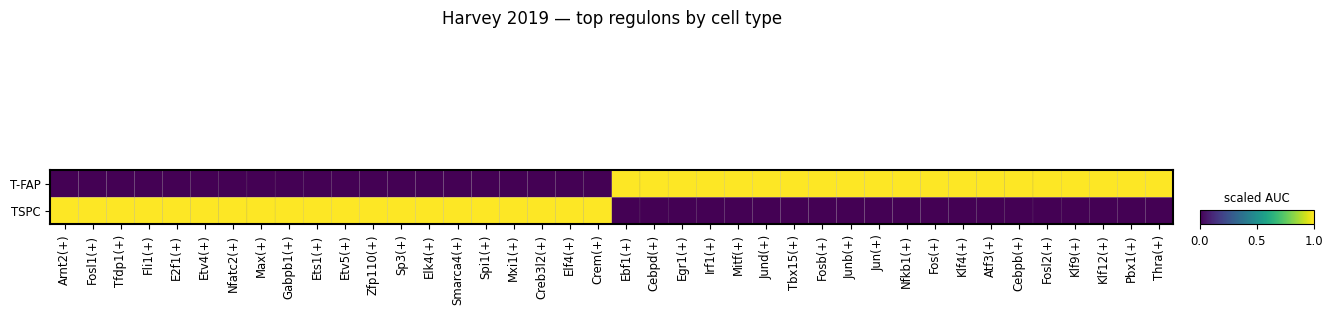

C:\Users\fangy\AppData\Local\Temp\ipykernel_16648\346676417.py:5: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.matrixplot(


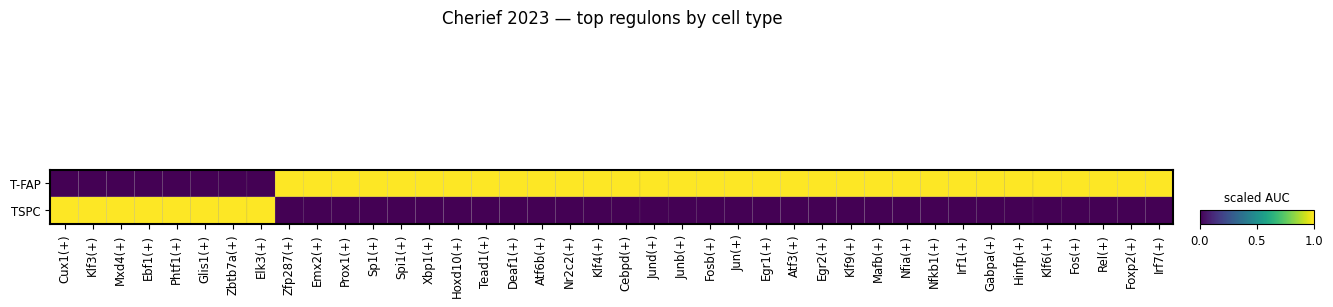

In [7]:
# Matrixplot: mean regulon activity per cell type
def plot_heatmap(adata, diff, name, label, top_n=20):
    top_regs = list(diff['TSPC']['names'].head(top_n)) + list(diff['T-FAP']['names'].head(top_n))
    top_regs = list(dict.fromkeys(r for r in top_regs if r in adata.var_names))
    sc.pl.matrixplot(
        adata, var_names=top_regs, groupby='cell_type',
        use_raw=False, standard_scale='var',
        title=f'{label} — top regulons by cell type',
        colorbar_title='scaled AUC',
        save=f'_heatmap_{name}.png'
    )

plot_heatmap(adata_h, diff_h, 'harvey',  'Harvey 2019')
plot_heatmap(adata_c, diff_c, 'cherief', 'Cherief 2023')

In [8]:
# Export per-dataset differential regulon tables
for name, diff in [('harvey', diff_h), ('cherief', diff_c)]:
    for ct, df in diff.items():
        out = DATA / f'{name}_diff_regulons_{ct}.csv'
        df.to_csv(out, index=False)
        print(f'Saved: {out}')

# Export cleaned shared regulon table (consistent direction in both datasets)
rows = []
for ct, regs in shared.items():
    h_df = diff_h[ct].set_index('names')
    c_df = diff_c[ct].set_index('names')
    for reg in regs:
        rows.append({
            'regulon':       reg,
            'cell_type':     ct,
            'harvey_score':  h_df.loc[reg, 'scores'],
            'cherief_score': c_df.loc[reg, 'scores'],
            'harvey_logfc':  h_df.loc[reg, 'logfoldchanges'],
            'cherief_logfc': c_df.loc[reg, 'logfoldchanges'],
        })

shared_df = pd.DataFrame(rows).sort_values(['cell_type', 'harvey_score'], ascending=[True, False])
out = DATA / 'shared_diff_regulons.csv'
shared_df.to_csv(out, index=False)
print(f'\nCleaned shared regulons saved: {out}')
shared_df

Saved: ..\..\data\pyscenic\harvey_diff_regulons_TSPC.csv
Saved: ..\..\data\pyscenic\harvey_diff_regulons_T-FAP.csv
Saved: ..\..\data\pyscenic\cherief_diff_regulons_TSPC.csv
Saved: ..\..\data\pyscenic\cherief_diff_regulons_T-FAP.csv

Cleaned shared regulons saved: ..\..\data\pyscenic\shared_diff_regulons.csv


,regulon,cell_type,harvey_score,cherief_score,harvey_logfc,cherief_logfc
1,Cebpd(+),T-FAP,20.779316,29.314266,2.396348,2.636666
2,Egr1(+),T-FAP,20.603586,25.893581,0.901675,0.776463
5,Irf1(+),T-FAP,20.546682,20.834347,1.092458,0.846436
8,Jund(+),T-FAP,18.148964,28.431025,1.793698,0.696679
4,Fosb(+),T-FAP,17.838593,26.718578,0.831600,1.270578
7,Junb(+),T-FAP,17.365801,27.267511,0.689496,1.126844
6,Jun(+),T-FAP,16.775726,26.297634,2.550428,1.783258
11,Nfkb1(+),T-FAP,15.078421,21.235260,0.765919,0.763009
3,Fos(+),T-FAP,14.255134,17.516514,1.434766,0.779407
0,Atf3(+),T-FAP,11.003265,25.695847,0.401571,0.998049
